# Music Genre Classification using GTZAN Dataset

## 1. Business Understanding

### Problem Statement
Music genre classification is a fundamental problem in the field of music information retrieval (MIR). With the exponential growth of digital music libraries and streaming platforms, automatically categorizing music into genres has become crucial for:

- **Music Discovery**: Helping users find new music based on their preferences
- **Content Organization**: Organizing large digital music libraries efficiently
- **Recommendation Systems**: Powering music recommendation algorithms
- **Intellectual Property**: Assisting in copyright detection and management

### Project Objective
The goal of this project is to build a machine learning model that can accurately classify audio tracks into one of 10 distinct music genres using extracted audio features from the GTZAN dataset.

**Genres to Classify**: Blues, Classical, Country, Disco, Hip-hop, Jazz, Metal, Pop, Reggae, Rock

### Success Criteria
- Achieve high classification accuracy across all genres
- Build a robust model that generalizes well to unseen audio data
- Understand which audio features are most discriminative for genre classification

This analysis will follow a comprehensive ML pipeline: data collection, preprocessing, exploratory analysis, feature engineering, model training, and evaluation.


---

## 2. Data Collection

### Dataset Overview
The GTZAN dataset is a widely-used benchmark dataset in music genre classification. It contains audio tracks from 10 different genres, with each track segmented into 3-second clips. The features extracted from these clips include:

- **MFCCs (Mel-frequency Cepstral Coefficients)**: 20 coefficients capturing timbral characteristics
- **Spectral Features**: Centroid, bandwidth, rolloff, zero-crossing rate
- **Chroma Features**: Representing harmonic content
- **RMS Energy**: Root Mean Square energy for loudness estimation
- **Harmony and Perceptr**: Additional timbral features
- **Tempo**: Beat tracking information

Let's load the dataset and examine its structure.


In [376]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")

# print("Path to dataset files:", path)

In [377]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")


Libraries imported successfully!


In [378]:
# Load the dataset
df = pd.read_csv(r'Data\features_3_sec.csv')

# Display basic information about the dataset
print("="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"\nShape of dataset: {df.shape}")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

print("\n" + "="*80)
print("FIRST FEW ROWS")
print("="*80)
df.head()


DATASET OVERVIEW

Shape of dataset: (9990, 60)
Number of samples: 9990
Number of features: 60

FIRST FEW ROWS


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


In [379]:
# Display dataset information
print("="*80)
print("DATASET INFORMATION")
print("="*80)
df.info()


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9990 entries, 0 to 9989
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   filename                 9990 non-null   object 
 1   length                   9990 non-null   int64  
 2   chroma_stft_mean         9990 non-null   float64
 3   chroma_stft_var          9990 non-null   float64
 4   rms_mean                 9990 non-null   float64
 5   rms_var                  9990 non-null   float64
 6   spectral_centroid_mean   9990 non-null   float64
 7   spectral_centroid_var    9990 non-null   float64
 8   spectral_bandwidth_mean  9990 non-null   float64
 9   spectral_bandwidth_var   9990 non-null   float64
 10  rolloff_mean             9990 non-null   float64
 11  rolloff_var              9990 non-null   float64
 12  zero_crossing_rate_mean  9990 non-null   float64
 13  zero_crossing_rate_var   9990 non-null   float64
 14  harm

In [380]:
# Statistical summary
print("="*80)
print("STATISTICAL SUMMARY")
print("="*80)
df.describe()


STATISTICAL SUMMARY


,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
count,9990.0,9990.000000,9990.000000,9990.000000,9.990000e+03,9990.000000,9.990000e+03,9990.000000,9.990000e+03,9990.000000,...,9990.000000,9990.000000,9990.000000,9990.000000,9990.000000,9990.000000,9990.000000,9990.000000,9990.000000,9990.000000
mean,66149.0,0.379534,0.084876,0.130859,2.676388e-03,2199.219431,4.166727e+05,2241.385959,1.182711e+05,4566.076592,...,1.448240,49.988755,-4.198706,51.962753,0.739943,52.488851,-2.497306,54.973829,-0.917584,57.322614
std,0.0,0.090466,0.009637,0.068545,3.585628e-03,751.860611,4.349644e+05,543.854449,1.013505e+05,1642.065335,...,5.735149,34.442816,5.677379,36.400669,5.181313,38.177120,5.111799,41.585677,5.253243,46.444212
min,66149.0,0.107108,0.015345,0.000953,4.379535e-08,472.741636,8.118813e+02,499.162910,1.183520e+03,658.336276,...,-26.850016,1.325786,-27.809795,1.624544,-20.733809,3.437439,-27.448456,3.065302,-35.640659,0.282131
25%,66149.0,0.315698,0.079833,0.083782,6.145900e-04,1630.680158,1.231961e+05,1887.455790,4.876553e+04,3378.311110,...,-2.227478,29.584894,-7.951722,29.863448,-2.516638,29.636197,-5.734123,30.496412,-4.004475,30.011365
50%,66149.0,0.384741,0.085108,0.121253,1.491318e-03,2208.628236,2.650692e+05,2230.575595,8.996072e+04,4631.377892,...,1.461623,41.702393,-4.443021,42.393583,0.733772,41.831377,-2.702366,43.435253,-1.030939,44.332155
75%,66149.0,0.442443,0.091092,0.176328,3.130862e-03,2712.581884,5.624152e+05,2588.340505,1.585674e+05,5591.634521,...,5.149752,59.274619,-0.726945,61.676964,3.888734,62.033906,0.514246,65.328602,2.216603,68.210421
max,66149.0,0.749481,0.120964,0.442567,3.261522e-02,5432.534406,4.794119e+06,3708.147554,1.235143e+06,9487.446477,...,39.144405,683.932556,34.048843,529.363342,36.970322,629.729797,31.365425,1143.230591,34.212101,910.473206


--------------------------------------------------------------------------------
3.3 GENRE DISTRIBUTION ANALYSIS
--------------------------------------------------------------------------------
Samples per genre:
label
blues        1000
classical     998
country       997
disco         999
hiphop        998
jazz         1000
metal        1000
pop          1000
reggae       1000
rock          998
Name: count, dtype: int64

Total number of genres: 10


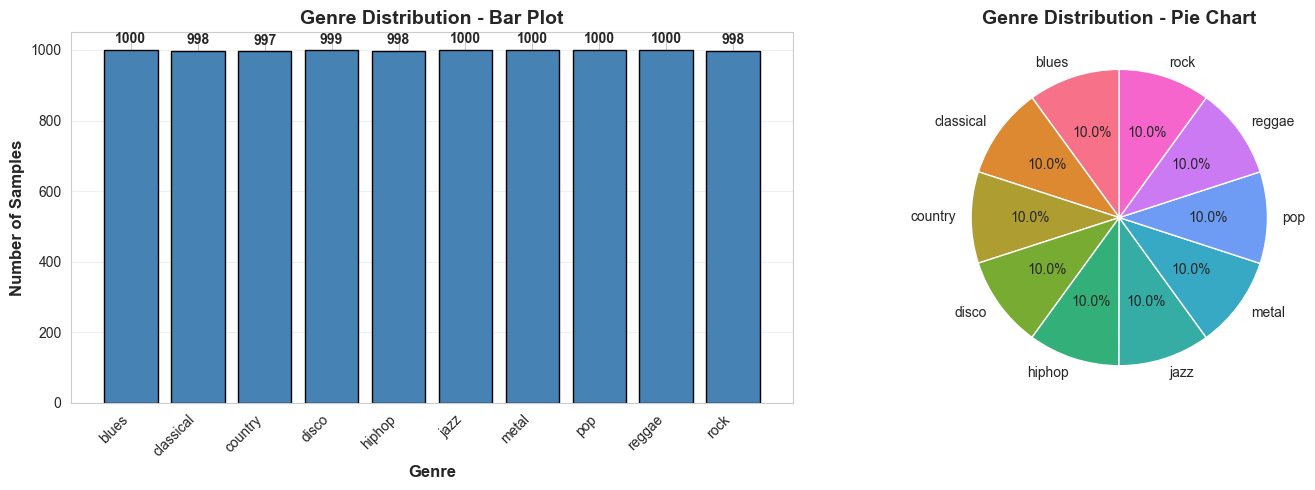

In [381]:
print("-"*80)
print("3.3 GENRE DISTRIBUTION ANALYSIS")
print("-"*80)

# Count samples per genre
genre_counts = df['label'].value_counts().sort_index()
print("Samples per genre:")
print(genre_counts)
print()

# Calculate statistics
print(f"Total number of genres: {df['label'].nunique()}")

# Visualize genre distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot
axes[0].bar(range(len(genre_counts)), genre_counts.values, color='steelblue', edgecolor='black')
axes[0].set_xticks(range(len(genre_counts)))
axes[0].set_xticklabels(genre_counts.index, rotation=45, ha='right')
axes[0].set_xlabel('Genre', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
axes[0].set_title('Genre Distribution - Bar Plot', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(genre_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')

# Pie chart
colors = sns.color_palette('husl', len(genre_counts))
axes[1].pie(genre_counts.values, labels=genre_counts.index, autopct='%1.1f%%',
            startangle=90, colors=colors)
axes[1].set_title('Genre Distribution - Pie Chart', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

---

## 3. Data Preprocessing and Data Preparation

### Preprocessing Steps

Data preprocessing is crucial for building an effective machine learning model. We will:

1. **Handle Missing Values**: Check for and handle any null or missing data
2. **Remove Duplicates**: Identify and drop duplicate records
3. **Outlier Detection**: Identify and analyze outliers in the data
4. **Encode Categorical Features**: Convert genre labels to numerical format
5. **Feature Scaling**: Standardize features to have similar scales
6. **Dimensionality Reduction**: Apply PCA analysis to understand feature space
7. **(Optional) Feature Binning/Binarization**: Binning continuous features to improve model interpretability

Let's start by examining the data quality.


### Train-Test Split (Stratified)
#### Stratified Splitting:
We use stratified splitting to ensure that both training and test sets 
have the same proportion of each genre class. This is crucial for:
- Balanced evaluation
- Preventing bias toward majority classes
- Fair model comparison

Split ratio: 80% training, 20% testing

In [382]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Assuming your dataset is already loaded
# and that the target column is named 'label'
# (change this to match your actual label column)
target_col = 'label'

# Stratified split — keeps same class proportions in train & test
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df[target_col],
    random_state=42
)

# Save raw splits before cleaning
train_df.to_csv(r"cleaned_data\train_raw.csv", index=False)
test_df.to_csv(r"cleaned_data\test_raw.csv", index=False)

# Keep a copy of the original dataset if needed
main_df = df.copy()

# Use train_df for cleaning and preprocessing
df = train_df

print("Shape of train_df", df.shape)
print("Shape of test_df", test_df.shape)
df['label'].nunique()

Shape of train_df (7992, 60)
Shape of test_df (1998, 60)


10

### 3.1 Handling Missing Values

First, let's check for missing values in our dataset.


In [383]:
# Check for missing values
print("="*80)
print("MISSING VALUES CHECK")
print("="*80)
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"\nMissing values per column:")
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage': missing_percentage
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
if len(missing_df) > 0:
    print(missing_df)
else:
    print("No missing values found!")

# Since there are no missing values, we can proceed to duplicate check
print("\n✓ No missing values detected. Dataset is clean in this regard.")


MISSING VALUES CHECK

Total missing values: 0

Missing values per column:
No missing values found!

✓ No missing values detected. Dataset is clean in this regard.


### 3.2 Checking for Duplicates

Duplicate samples can bias our model and reduce its generalization ability. Let's identify and remove them.


In [384]:
# Check for duplicate rows
print("="*80)
print("DUPLICATE ROWS CHECK")
print("="*80)
print(f"\nOriginal shape: {df.shape}")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

if df.duplicated().sum() > 0:
    print("\nRemoving duplicate rows...")
    df_cleaned = df.drop_duplicates().reset_index(drop=True)
    print(f"Shape after removing duplicates: {df_cleaned.shape}")
    print(f"Dropped {len(df) - len(df_cleaned)} duplicate rows.")
else:
    df_cleaned = df.copy()
    print("\n✓ No duplicate rows found. Dataset is clean!")

print(f"\nFinal shape: {df_cleaned.shape}")


DUPLICATE ROWS CHECK

Original shape: (7992, 60)
Number of duplicate rows: 0

✓ No duplicate rows found. Dataset is clean!

Final shape: (7992, 60)


### 3.3 Outlier Detection and Treatment

Outliers are data points that deviate significantly from other observations. They can negatively impact model performance. We'll detect and handle outliers using the Interquartile Range (IQR) method.


Number of numeric features: 58



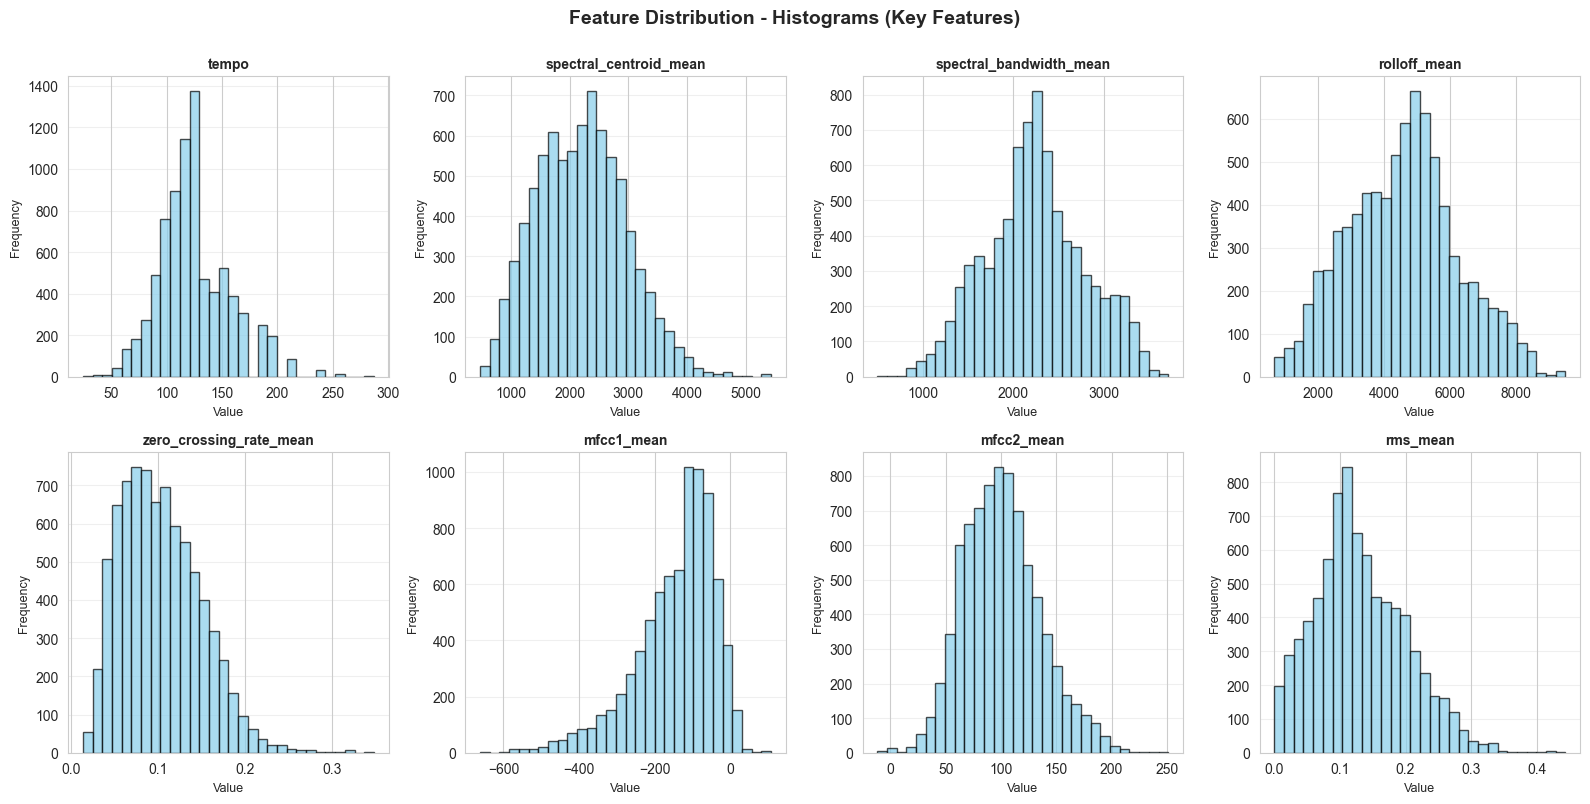

In [385]:
# Select only numeric columns (exclude filename and label)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Number of numeric features: {len(numeric_cols)}")
print()

# Plot histograms for a subset of key features
key_features = ['tempo', 'spectral_centroid_mean', 'spectral_bandwidth_mean', 
                'rolloff_mean', 'zero_crossing_rate_mean', 'mfcc1_mean', 
                'mfcc2_mean', 'rms_mean']

# Filter to only include features that exist in the dataset
available_key_features = [f for f in key_features if f in df.columns]

if len(available_key_features) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()
    
    for idx, feature in enumerate(available_key_features[:8]):
        axes[idx].hist(df[feature].dropna(), bins=30, color='skyblue', 
                      edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{feature}', fontsize=10, fontweight='bold')
        axes[idx].set_xlabel('Value', fontsize=9)
        axes[idx].set_ylabel('Frequency', fontsize=9)
        axes[idx].grid(axis='y', alpha=0.3)
    
    plt.suptitle('Feature Distribution - Histograms (Key Features)', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()


--------------------------------------------------------------------------------
3.5 OUTLIER DETECTION ANALYSIS
--------------------------------------------------------------------------------


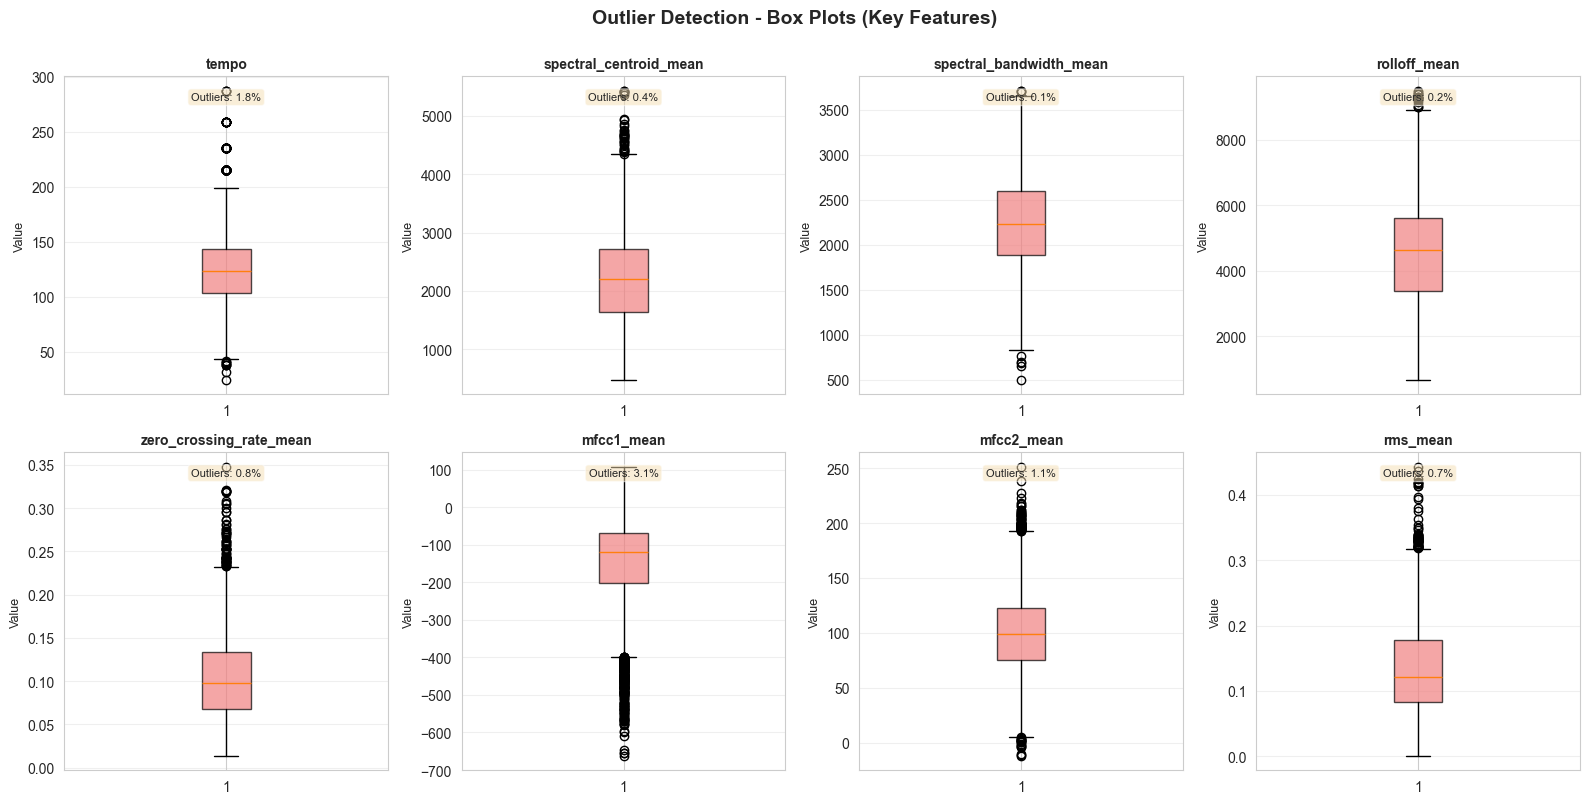


✓ Box plots help visualize outliers (points beyond whiskers).
  Decision: Keep outliers as they may be meaningful for genre classification.


In [386]:
print("-"*80)
print("3.5 OUTLIER DETECTION ANALYSIS")
print("-"*80)

# Plot boxplots for the same key features
if len(available_key_features) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()
    
    for idx, feature in enumerate(available_key_features[:8]):
        # Remove NaN values for boxplot
        data = df[feature].dropna()
        
        box = axes[idx].boxplot(data, vert=True, patch_artist=True)
        box['boxes'][0].set_facecolor('lightcoral')
        box['boxes'][0].set_alpha(0.7)
        
        axes[idx].set_title(f'{feature}', fontsize=10, fontweight='bold')
        axes[idx].set_ylabel('Value', fontsize=9)
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Calculate outlier statistics
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
        outlier_pct = (len(outliers) / len(data)) * 100
        
        axes[idx].text(0.5, 0.95, f'Outliers: {outlier_pct:.1f}%', 
                      transform=axes[idx].transAxes, ha='center', va='top',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                      fontsize=8)
    
    plt.suptitle('Outlier Detection - Box Plots (Key Features)', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

print("\n✓ Box plots help visualize outliers (points beyond whiskers).")
print("  Decision: Keep outliers as they may be meaningful for genre classification.")

### Outlier Detection Strategy:
There are multiple methods to detect outliers:
1. **IQR Method**: Interquartile Range (Q3 - Q1)
   - Outliers: Values < Q1 - 1.5*IQR or > Q3 + 1.5*IQR
2. **Z-Score Method**: Statistical measure of distance from mean
   - Outliers: |Z-score| > 3

For music features, some extreme values may be legitimate genre characteristics.
We will cap outliers using the IQR method (Winsorization) rather than removing them.

Analyzing outliers in 57 numeric features...

⚠️ Features with more than 5% outliers (before capping):

               Feature  Outliers (%)
          harmony_mean         21.52
         perceptr_mean         14.03
zero_crossing_rate_var          9.08
               rms_var          9.05
            mfcc20_var          6.67
          perceptr_var          6.43
            mfcc19_var          6.37
            mfcc18_var          6.32
 spectral_centroid_var          5.92
            mfcc17_var          5.89

✓ Outliers handled using IQR Winsorization method
  Total features with >5% outliers: 13


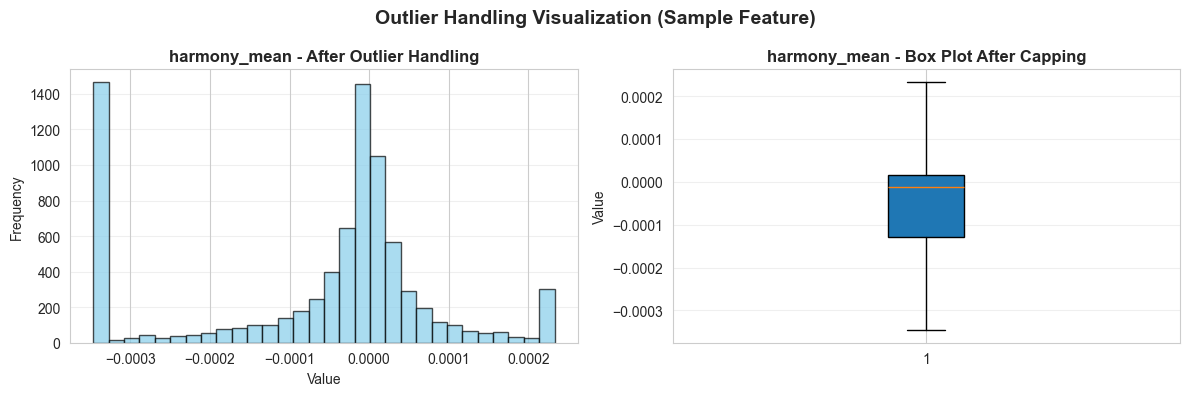

In [387]:
# ==========================================
# OUTLIER DETECTION & HANDLING (IQR METHOD)
# ==========================================

# Select numeric columns only (exclude filename, label)
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove non-feature metadata columns
for col in ['length']:
    if col in numeric_features:
        numeric_features.remove(col)

print(f"Analyzing outliers in {len(numeric_features)} numeric features...\n")

# IQR-based outlier detection and capping
outlier_summary = []

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outliers
    outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    num_outliers = outlier_mask.sum()
    total = len(df)
    outlier_pct = (num_outliers / total) * 100
    
    # Cap outliers (Winsorization)
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    
    # Store result
    outlier_summary.append({
        'Feature': col,
        'Outliers (%)': round(outlier_pct, 2)
    })

# Convert to DataFrame
outlier_df = pd.DataFrame(outlier_summary)

# Filter for features with >5% outliers
outlier_df_filtered = outlier_df[outlier_df['Outliers (%)'] > 5].sort_values(
    by='Outliers (%)', ascending=False
)

# Display summary
if not outlier_df_filtered.empty:
    print("⚠️ Features with more than 5% outliers (before capping):\n")
    print(outlier_df_filtered.head(10).to_string(index=False))
    print(f"\n✓ Outliers handled using IQR Winsorization method")
    print(f"  Total features with >5% outliers: {len(outlier_df_filtered)}")
else:
    print("✓ No features had more than 5% outliers detected.\n")

# ==========================================
# Visualization (Sample Feature)
# ==========================================

if len(numeric_features) > 0:
    sample_feature = outlier_df_filtered['Feature'].iloc[0] if not outlier_df_filtered.empty else numeric_features[0]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram after capping
    axes[0].hist(df[sample_feature], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0].set_title(f'{sample_feature} - After Outlier Handling', fontweight='bold')
    axes[0].set_xlabel('Value')
    axes[0].set_ylabel('Frequency')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Boxplot after capping
    axes[1].boxplot(df[sample_feature], vert=True, patch_artist=True)
    axes[1].set_title(f'{sample_feature} - Box Plot After Capping', fontweight='bold')
    axes[1].set_ylabel('Value')
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.suptitle('Outlier Handling Visualization (Sample Feature)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


### 3.3 Label Encoding for Categorical Features

The genre labels are categorical strings. We need to encode them into numerical format for machine learning algorithms.


In [388]:
# Encode genre labels
print("="*80)
print("LABEL ENCODING")
print("="*80)

# Create LabelEncoder
label_encoder = LabelEncoder()

# Create a copy for encoding
df_preprocessed = df_cleaned.copy()

# Encode labels
df_preprocessed['label_encoded'] = label_encoder.fit_transform(df_preprocessed['label'])

# Display the mapping
print("\nGenre to Numerical Label Mapping:")
label_mapping = pd.DataFrame({
    'Genre': label_encoder.classes_,
    'Encoded_Value': range(len(label_encoder.classes_))
})
print(label_mapping.to_string(index=False))

# Display first few rows to verify
print("\n" + "="*80)
print("VERIFICATION - Random 10 rows")
print("="*80)
print(df_preprocessed[['filename', 'label', 'label_encoded']].sample(10))
print("\nShape of the dataset after encoding:", df_preprocessed.shape)

# We will apply the same label encoding for the test_raw.csv for easier use in the future
test_df['label_encoded'] = label_encoder.transform(test_df['label'])
test_df.to_csv(r'cleaned_data\test_raw.csv')
df_preprocessed.to_csv(r'cleaned_data\train_raw.csv')


LABEL ENCODING

Genre to Numerical Label Mapping:
    Genre  Encoded_Value
    blues              0
classical              1
  country              2
    disco              3
   hiphop              4
     jazz              5
    metal              6
      pop              7
   reggae              8
     rock              9

VERIFICATION - Random 10 rows
                   filename      label  label_encoded
7306        pop.00031.4.wav        pop              7
5196       jazz.00020.4.wav       jazz              5
8903     reggae.00091.1.wav     reggae              8
9270       rock.00027.8.wav       rock              9
889       blues.00088.9.wav      blues              0
9674       rock.00068.4.wav       rock              9
4283     hiphop.00028.9.wav     hiphop              4
7862        pop.00087.0.wav        pop              7
8771     reggae.00077.9.wav     reggae              8
1369  classical.00036.9.wav  classical              1

Shape of the dataset after encoding: (7992, 61)


### 3.4 Separating Features and Target

Before scaling, we need to separate our features (X) from the target variable (y) and exclude non-numerical columns like filename.


In [389]:
# Separate features and target
print("="*80)
print("SEPARATING FEATURES AND TARGET")
print("="*80)

# Exclude non-numerical columns and the encoded label
columns_to_exclude = ['filename', 'label', 'label_encoded']
X = df_preprocessed.drop(columns=columns_to_exclude, axis=1)

# Target variable
y = df_preprocessed['label_encoded']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {len(X.columns)}")
print(f"\nFirst few feature column names:")
print(X.columns.tolist()[:10])

# Save the actual genre labels for later use
y_genres = df_preprocessed['label'].values
print(f"\nGenre labels: {sorted(df_preprocessed['label'].unique())}")
print(f"Number of unique genres: {df_preprocessed['label'].nunique()}")

SEPARATING FEATURES AND TARGET

Features shape: (7992, 58)
Target shape: (7992,)

Feature columns: 58

First few feature column names:
['length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean']

Genre labels: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Number of unique genres: 10


### 3.5 Feature Scaling

Machine learning algorithms perform better when features are on a similar scale. We'll use StandardScaler to normalize features to have zero mean and unit variance.

**Why scaling?**
- Many ML algorithms are sensitive to feature scales
- Prevents features with larger scales from dominating the model
- Speeds up convergence in optimization algorithms


In [390]:
# Apply feature scaling
print("="*80)
print("FEATURE SCALING")
print("="*80)

# Create scaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier handling
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("\n✓ Features scaled successfully!")
print(f"\nScaled features shape: {X_scaled_df.shape}")

# Display statistical summary of scaled features
print("\n" + "="*80)
print("STATISTICS OF SCALED FEATURES")
print("="*80)
print("\nMean and Std of first 5 scaled features:")
stats_df = pd.DataFrame({
    'Mean': X_scaled_df.iloc[:, :5].mean(),
    'Std': X_scaled_df.iloc[:, :5].std()
})
print(stats_df)

print("\n✓ As expected, scaled features have mean ≈ 0 and std ≈ 1")


FEATURE SCALING

✓ Features scaled successfully!

Scaled features shape: (7992, 58)

STATISTICS OF SCALED FEATURES

Mean and Std of first 5 scaled features:
                          Mean       Std
length            0.000000e+00  0.000000
chroma_stft_mean -5.334405e-18  1.000063
chroma_stft_var  -1.436733e-15  1.000063
rms_mean         -7.245900e-16  1.000063
rms_var          -8.535048e-17  1.000063

✓ As expected, scaled features have mean ≈ 0 and std ≈ 1


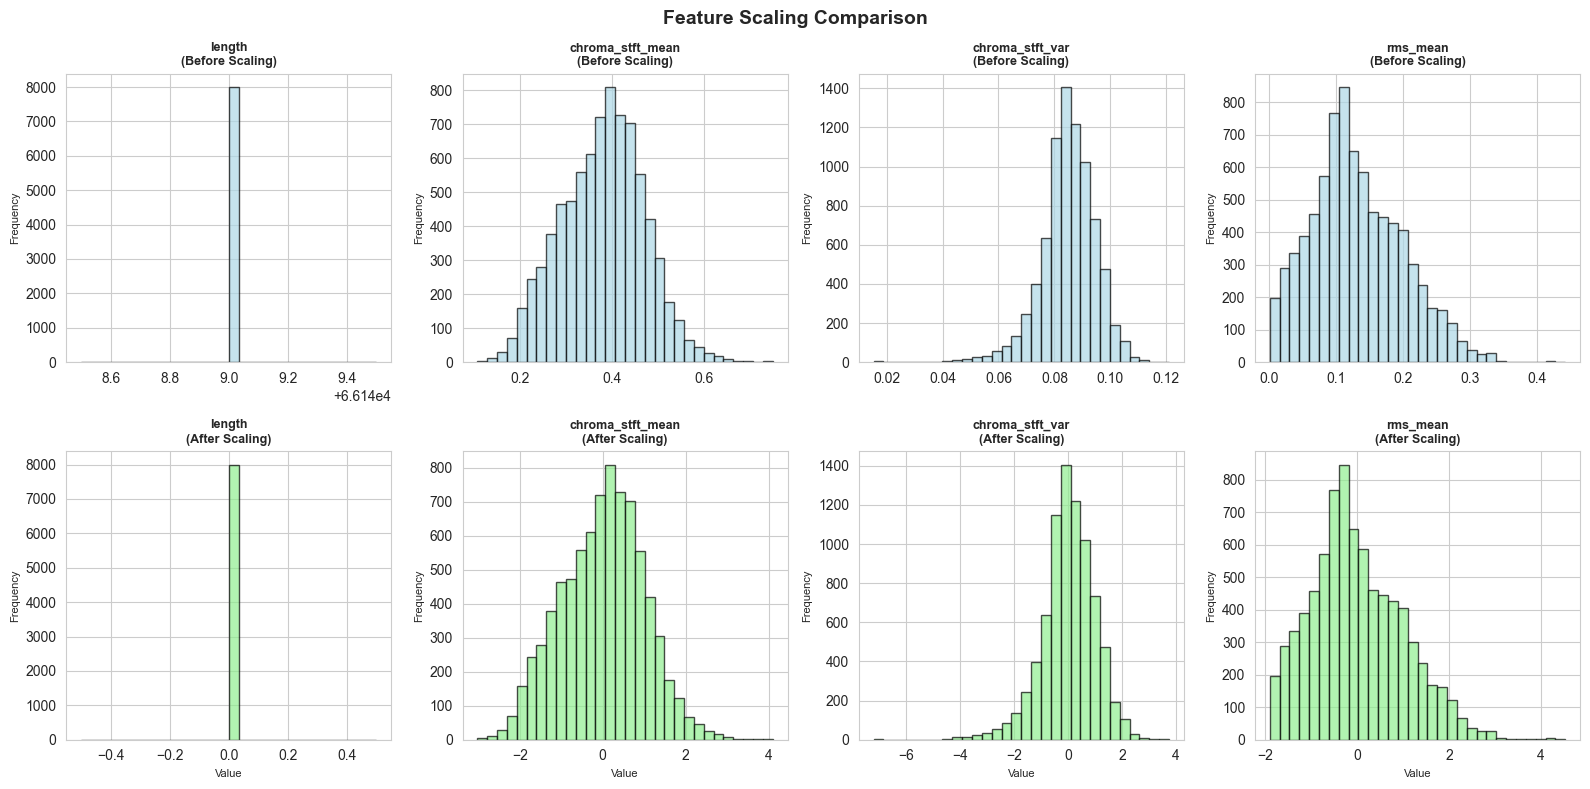

In [391]:
# Visualize scaling effect
if len(X.columns) >= 4:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    for i, col in enumerate(X.columns[:4]):
        # Before scaling
        axes[0, i].hist(X[col], bins=30, color='lightblue', edgecolor='black', alpha=0.7)
        axes[0, i].set_title(f'{col}\n(Before Scaling)', fontsize=9, fontweight='bold')
        axes[0, i].set_ylabel('Frequency', fontsize=8)
        
        # After scaling
        axes[1, i].hist(X_scaled_df[col], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
        axes[1, i].set_title(f'{col}\n(After Scaling)', fontsize=9, fontweight='bold')
        axes[1, i].set_xlabel('Value', fontsize=8)
        axes[1, i].set_ylabel('Frequency', fontsize=8)
    
    plt.suptitle('Feature Scaling Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 3.6 Dimensionality Reduction with PCA

We will apply **Principal Component Analysis (PCA)** for dimensionality reduction because:

**Why PCA over LDA?**
1. **PCA** is unsupervised - finds directions of maximum variance in data
   - Better for capturing intrinsic data structure
   - Reduces risk of overfitting
   - More generalizable

2. **LDA** is supervised - finds directions that maximize class separation
   - Requires labeled data
   - Limited to (n_classes - 1) components (max 9 for 10 genres)
   - More prone to overfitting on training data

For music genre classification with high-dimensional audio features, PCA is more suitable
as it preserves the most important variance patterns without being constrained by class labels.

**Strategy:**
- Apply PCA to retain 95% of variance
- Analyze explained variance ratio
- Select optimal number of components


Original number of features: 58
Number of components after PCA (95% variance): 39
Variance retained: 95.30%

Explained variance by first 10 components:
  PC1: 20.10% (Cumulative: 20.10%)
  PC2: 13.52% (Cumulative: 33.61%)
  PC3: 10.34% (Cumulative: 43.96%)
  PC4: 6.64% (Cumulative: 50.60%)
  PC5: 4.41% (Cumulative: 55.00%)
  PC6: 3.66% (Cumulative: 58.66%)
  PC7: 2.94% (Cumulative: 61.61%)
  PC8: 2.64% (Cumulative: 64.25%)
  PC9: 2.49% (Cumulative: 66.74%)
  PC10: 2.10% (Cumulative: 68.84%)



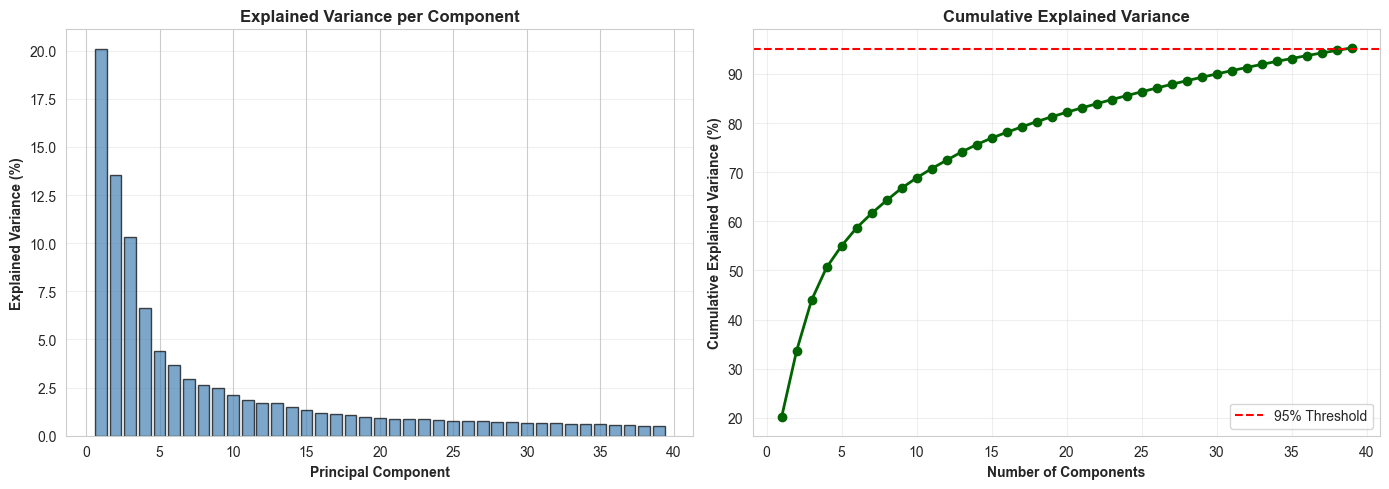

✓ PCA transformation completed successfully
  Dimensionality reduced from 58 to 39 features



In [392]:
from sklearn.decomposition import PCA

# Apply PCA with 95% variance retention
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Original number of features: {X_scaled.shape[1]}")
print(f"Number of components after PCA (95% variance): {X_pca.shape[1]}")
print(f"Variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print()

# Display explained variance per component
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Explained variance by first 10 components:")
for i in range(min(10, len(explained_variance))):
    print(f"  PC{i+1}: {explained_variance[i]*100:.2f}% "
          f"(Cumulative: {cumulative_variance[i]*100:.2f}%)")
print()

# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual explained variance
axes[0].bar(range(1, len(explained_variance)+1), explained_variance*100, 
            color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Principal Component', fontweight='bold')
axes[0].set_ylabel('Explained Variance (%)', fontweight='bold')
axes[0].set_title('Explained Variance per Component', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Cumulative explained variance
axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance*100, 
             marker='o', color='darkgreen', linewidth=2, markersize=6)
axes[1].axhline(y=95, color='red', linestyle='--', label='95% Threshold')
axes[1].set_xlabel('Number of Components', fontweight='bold')
axes[1].set_ylabel('Cumulative Explained Variance (%)', fontweight='bold')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ PCA transformation completed successfully")
print(f"  Dimensionality reduced from {X_scaled.shape[1]} to {X_pca.shape[1]} features")
print()

I will also be implementing LDA and compare results with PCA during model training
### LDA Implementation Details:
LDA requires labeled data and finds directions that:
1. Maximize between-class variance
2. Minimize within-class variance

Maximum components = n_classes - 1 = 10 - 1 = 9 components

Number of genres (classes): 10
Maximum LDA components: 9

Original number of features: 58
Number of components after LDA: 9
Variance retained: 100.00%

Explained variance by all LDA components:
  LD1: 45.50% (Cumulative: 45.50%)
  LD2: 21.73% (Cumulative: 67.23%)
  LD3: 10.13% (Cumulative: 77.36%)
  LD4: 8.14% (Cumulative: 85.50%)
  LD5: 4.95% (Cumulative: 90.45%)
  LD6: 3.57% (Cumulative: 94.02%)
  LD7: 3.34% (Cumulative: 97.37%)
  LD8: 1.95% (Cumulative: 99.32%)
  LD9: 0.68% (Cumulative: 100.00%)



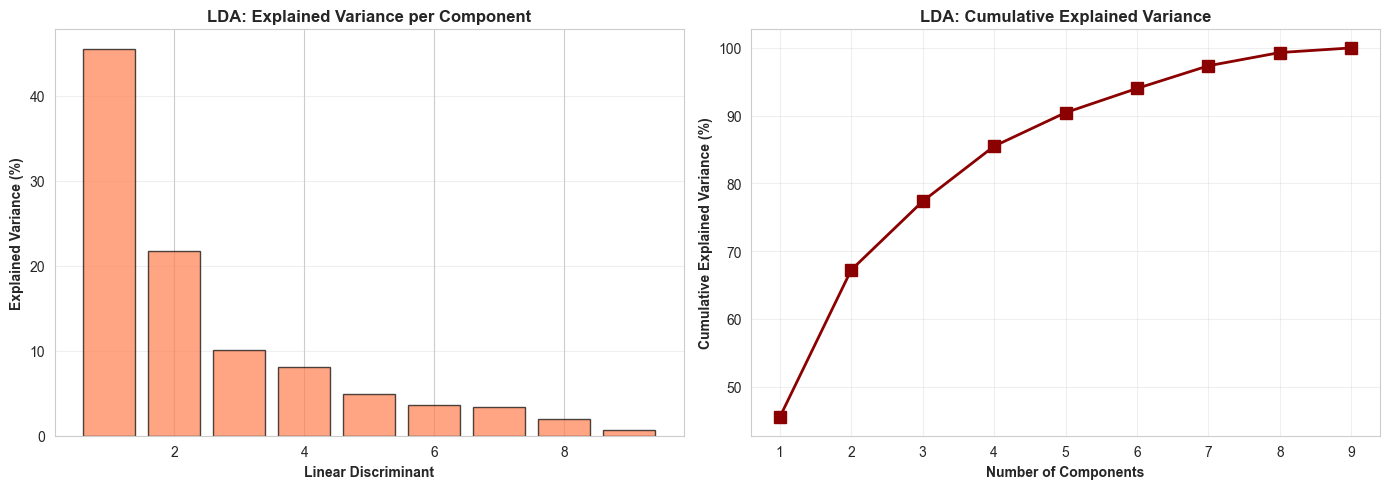

✓ LDA transformation completed successfully
  Dimensionality reduced from 58 to 9 features



In [393]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Apply LDA (maximum components = n_classes - 1)
n_components_lda = len(np.unique(y)) - 1
print(f"Number of genres (classes): {len(np.unique(y))}")
print(f"Maximum LDA components: {n_components_lda}")
print()

lda = LinearDiscriminantAnalysis(n_components=n_components_lda)
X_lda = lda.fit_transform(X_scaled, y)

print(f"Original number of features: {X_scaled.shape[1]}")
print(f"Number of components after LDA: {X_lda.shape[1]}")
print(f"Variance retained: {lda.explained_variance_ratio_.sum()*100:.2f}%")
print()

# Display explained variance per component
explained_variance_lda = lda.explained_variance_ratio_
cumulative_variance_lda = np.cumsum(explained_variance_lda)

print("Explained variance by all LDA components:")
for i in range(len(explained_variance_lda)):
    print(f"  LD{i+1}: {explained_variance_lda[i]*100:.2f}% "
          f"(Cumulative: {cumulative_variance_lda[i]*100:.2f}%)")
print()

# Visualize LDA explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual explained variance
axes[0].bar(range(1, len(explained_variance_lda)+1), explained_variance_lda*100, 
            color='coral', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Linear Discriminant', fontweight='bold')
axes[0].set_ylabel('Explained Variance (%)', fontweight='bold')
axes[0].set_title('LDA: Explained Variance per Component', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Cumulative explained variance
axes[1].plot(range(1, len(cumulative_variance_lda)+1), cumulative_variance_lda*100, 
             marker='s', color='darkred', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Components', fontweight='bold')
axes[1].set_ylabel('Cumulative Explained Variance (%)', fontweight='bold')
axes[1].set_title('LDA: Cumulative Explained Variance', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ LDA transformation completed successfully")
print(f"  Dimensionality reduced from {X_scaled.shape[1]} to {X_lda.shape[1]} features")
print()


In [394]:
# -------------------------------------------------------------------------
# Compare PCA vs LDA
# -------------------------------------------------------------------------

print("="*60)
print("PCA vs LDA COMPARISON")
print("="*60)
print()

comparison_data = {
    'Metric': ['Method Type', 'Components', 'Total Variance', 'Uses Labels'],
    'PCA': ['Unsupervised', X_pca.shape[1], f"{pca.explained_variance_ratio_.sum()*100:.2f}%", 'No'],
    'LDA': ['Supervised', X_lda.shape[1], f"{lda.explained_variance_ratio_.sum()*100:.2f}%", 'Yes']
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))
print()

PCA vs LDA COMPARISON

        Metric          PCA        LDA
   Method Type Unsupervised Supervised
    Components           39          9
Total Variance       95.30%    100.00%
   Uses Labels           No        Yes



### 3.7 Optional: Feature Binning/Binarization
For some applications, binning continuous features can help:
- Reduce noise and outliers
- Create categorical features from continuous ones
- Improve model interpretability

However, for music genre classification with PCA-transformed features,
binning is typically NOT recommended as it may lose important continuous information.

We will SKIP binning for this project to preserve the rich continuous feature space.

In [395]:
# Create final preprocessed dataset
df_preprocessed_pca = pd.DataFrame(
    X_pca, 
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])],
    index=X.index   # keep same index as original features
)


df_preprocessed_pca['genre_encoded'] = y.values

print("Final preprocessed dataset preview:")
print(df_preprocessed_pca.shape)
df_preprocessed_pca.sample(5)


Final preprocessed dataset preview:
(7992, 40)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39,genre_encoded
9548,-1.308538,-0.312332,-4.437066,-0.944010,-1.214665,1.199399,0.281603,1.259106,0.550735,-0.456195,...,0.686266,0.511117,-0.258497,-0.240928,0.742986,-0.290972,0.261423,-0.178792,0.351451,9
3286,1.985053,0.061162,-2.250052,2.177502,-1.758168,-0.287244,-0.116049,-0.102273,-0.678139,1.639713,...,0.608664,-0.238894,0.737698,-0.082546,0.656738,-0.520149,-0.399534,-0.225852,0.364356,3
2067,0.429933,2.941942,-2.027794,0.698544,0.110204,2.034862,0.724291,-1.712409,0.474181,0.814897,...,0.773580,0.974586,-0.396038,0.251768,-0.156532,0.723868,0.083376,0.270906,0.574401,2
3675,-3.649204,3.197136,1.941344,0.485962,-0.658160,-1.577501,0.168377,0.629413,0.771168,0.298009,...,-0.348283,-0.081132,-0.380566,-0.891505,-0.464587,0.341910,0.444142,0.238217,-0.119253,3
4923,-0.875342,2.466012,2.706408,-0.056062,0.750596,-1.981129,1.084871,0.085032,-0.063207,1.168352,...,0.117614,0.261944,-0.394215,-0.389038,-0.394654,-0.063689,0.455432,0.535435,-0.167000,4


In [396]:
df_preprocessed_lda = pd.DataFrame(
    X_lda, 
    columns=[f'LD{i+1}' for i in range(X_lda.shape[1])],
    index=X.index   # keep same index as original features
)

df_preprocessed_lda['genre_encoded'] = y.values

print("Final preprocessed dataset preview:")
print(df_preprocessed_lda.shape)
df_preprocessed_lda.sample(5)

Final preprocessed dataset preview:
(7992, 10)


,LD1,LD2,LD3,LD4,LD5,LD6,LD7,LD8,LD9,genre_encoded
8561,-1.518638,0.613372,0.790387,-1.907413,-2.624001,1.624009,0.385737,-1.369583,0.849915,8
9073,-0.101136,-1.199699,-0.969092,-0.815536,-0.395425,-1.113103,0.974573,0.566341,2.132680,9
4508,-1.561789,0.341194,0.953216,0.557894,1.820463,0.775092,-1.010361,0.242915,0.889513,4
5314,1.666603,-0.433466,0.733428,0.540754,0.593571,0.020462,1.732757,-0.790565,0.743346,5
9515,-0.609037,0.145015,-1.078928,-1.687495,-4.293071,1.264423,2.683301,1.067120,1.556256,9


In [397]:
X_scaled_df['genre_encoded'] = y
print("Final preprocessed dataset preview:")
print(X_scaled_df.shape)

X_scaled_df.sample(5)

Final preprocessed dataset preview:
(7992, 59)


,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,genre_encoded
536,0.0,0.548874,0.194868,0.686891,0.484778,-0.026135,-0.580094,-0.384454,-0.599048,-0.149307,...,-0.329540,-0.704489,0.255808,-0.384065,-0.018436,-0.145165,-0.153869,-0.546309,-0.265901,0
6606,0.0,1.817520,-1.466781,-0.399550,-0.610047,0.794488,-0.560644,-0.035635,-0.937647,0.403357,...,-0.620415,-1.317857,-0.558640,0.843804,-0.672639,-1.137598,-0.798190,0.371330,-0.414126,6
3050,0.0,1.376808,-1.302291,1.077810,-0.051985,0.440281,-0.247602,0.576120,-0.338137,0.377021,...,-0.797880,1.287972,-0.745884,-0.880696,-0.837404,-0.007900,-0.608085,-0.093404,-0.766256,3
4395,0.0,-1.100789,-0.159904,-0.709126,-0.429631,-1.039083,-0.129286,0.027587,2.088165,-1.045548,...,2.348583,-1.102929,0.664595,-2.086623,1.008045,-0.443051,0.939027,-0.898664,2.507133,4
2416,0.0,-0.296836,0.295307,-0.100495,-0.599095,0.367937,0.127434,1.057070,-0.194016,0.667624,...,-0.630639,-0.975897,-0.860034,-0.285493,-0.590809,-1.278754,-0.584180,-0.908951,-0.561022,2


In [398]:
import os

# Create the folder if it doesn't exist
os.makedirs("cleaned_data", exist_ok=True)

# Save the PCA-transformed data
df_preprocessed_pca.to_csv(r"cleaned_data\PCA_Processed_Data.csv", index=False)
print("✅ PCA data successfully saved in 'cleaned_data/PCA_Processed_Data.csv'")

df_preprocessed_lda.to_csv(r"cleaned_data\LDA_Processed_Data.csv", index=False)
print("✅ LDA data successfully saved in 'cleaned_data/LDA_Processed_Data.csv'")

X_scaled_df.to_csv(r"cleaned_data\Processed_Data.csv", index=False)
print("✅ Processed data successfully saved in 'cleaned_data/Processed_Data.csv'")

✅ PCA data successfully saved in 'cleaned_data/PCA_Processed_Data.csv'
✅ LDA data successfully saved in 'cleaned_data/LDA_Processed_Data.csv'
✅ Processed data successfully saved in 'cleaned_data/Processed_Data.csv'


---

## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand patterns, relationships, and distributions in our data. We'll perform:

1. **Univariate Analysis**: Examine individual feature distributions
2. **Bivariate Analysis**: Explore relationships between features and target variable
3. **Correlation Analysis**: Identify feature correlations

### 4.1 Univariate Analysis - Feature Distributions

Let's examine the distributions of some key audio features across different genres.


UNIVARIATE ANALYSIS - FEATURE DISTRIBUTIONS


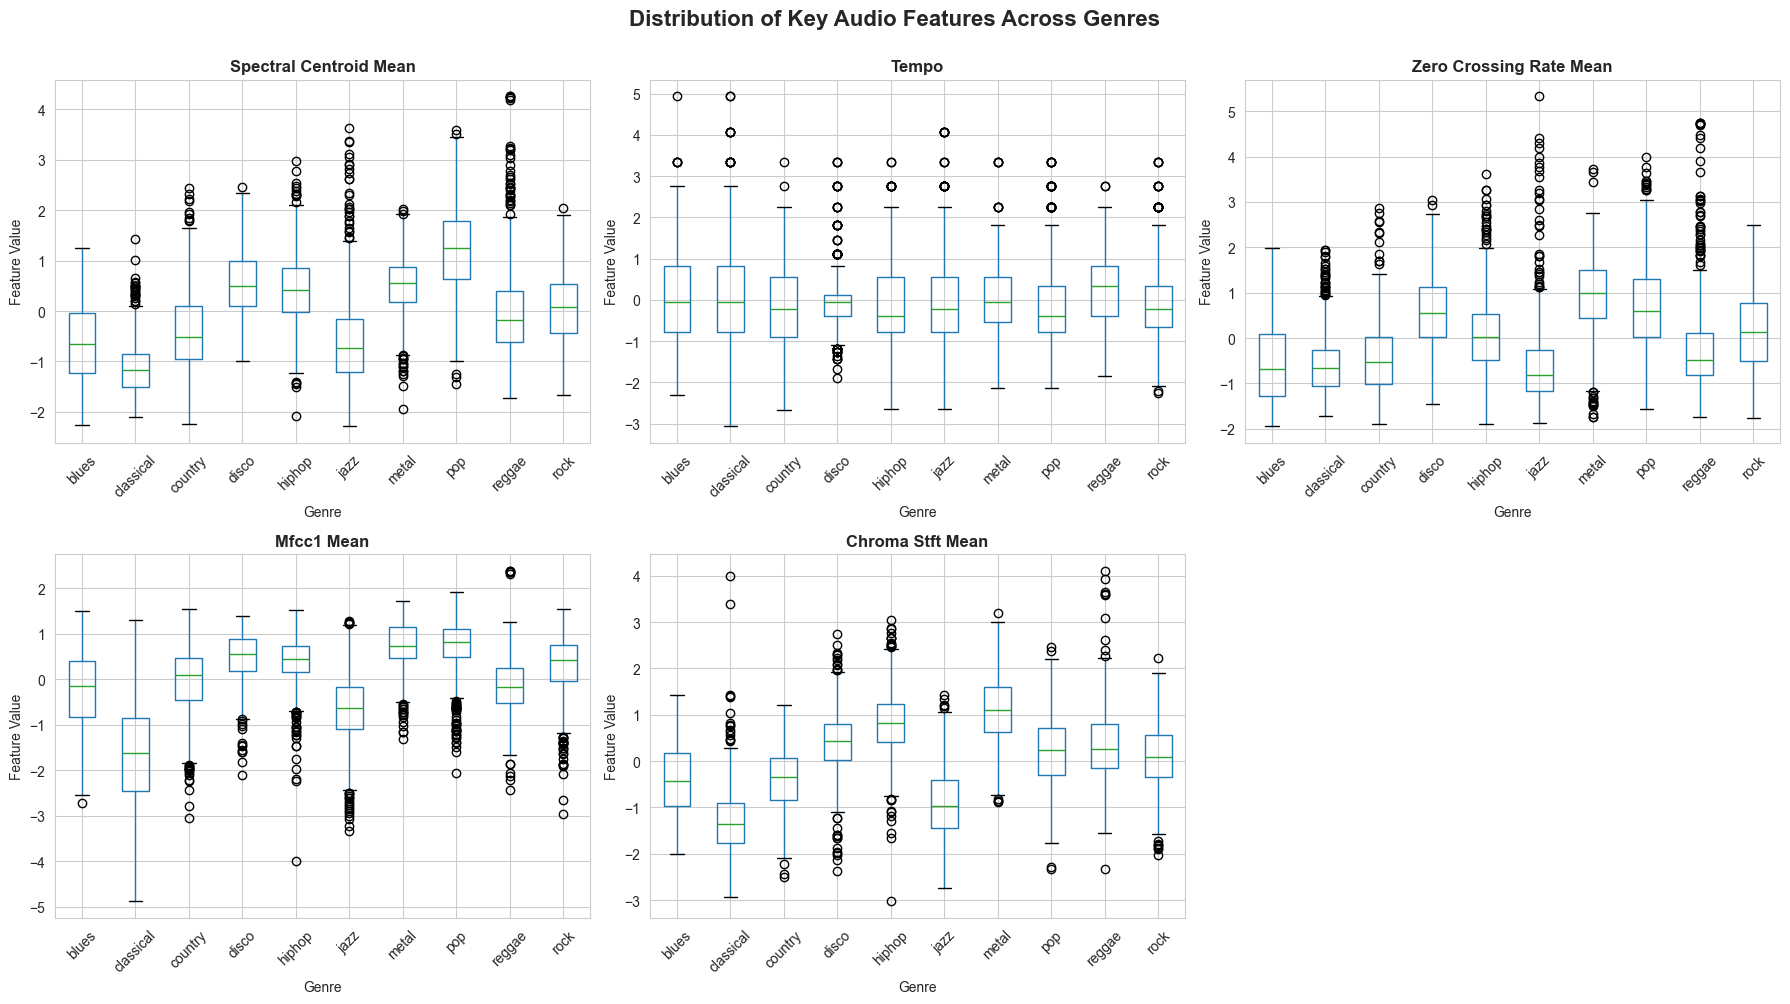


✓ Box plots show the distribution and variability of features across genres.


In [399]:
# Univariate analysis - Box plots for key features across genres
print("="*80)
print("UNIVARIATE ANALYSIS - FEATURE DISTRIBUTIONS")
print("="*80)

# Select a few key features to visualize
key_features = ['spectral_centroid_mean', 'tempo', 'zero_crossing_rate_mean', 
                'mfcc1_mean', 'chroma_stft_mean']

# Add genre labels back for analysis
X_analysis = X_scaled_df.copy()
X_analysis['genre'] = label_encoder.inverse_transform(y)

# Create subplots for box plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    if idx < len(axes):
        # Box plot by genre
        X_analysis.boxplot(column=feature, by='genre', ax=axes[idx])
        axes[idx].set_title(f'{feature.replace("_", " ").title()}', fontweight='bold')
        axes[idx].set_xlabel('Genre')
        axes[idx].set_ylabel('Feature Value')
        axes[idx].tick_params(axis='x', rotation=45)

# Remove the last empty subplot if needed
if len(key_features) < len(axes):
    fig.delaxes(axes[-1])

plt.suptitle('Distribution of Key Audio Features Across Genres', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n✓ Box plots show the distribution and variability of features across genres.")


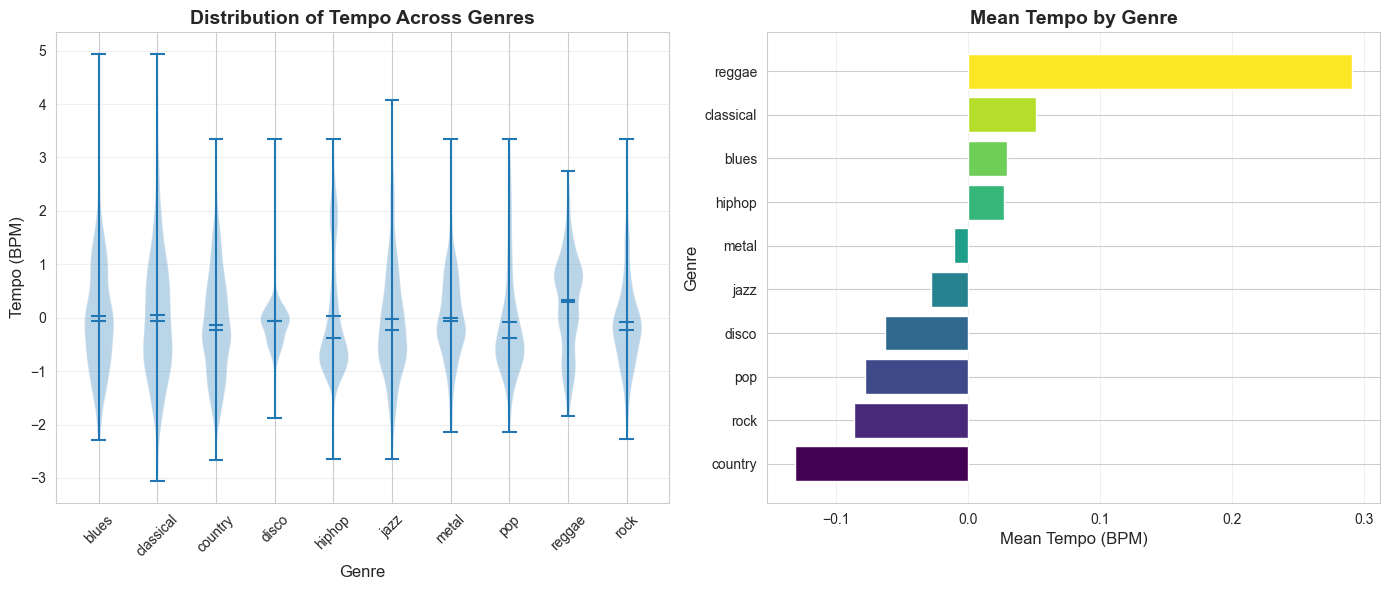


✓ Tempo analysis shows clear differences between genres (e.g., Classical vs Metal).


In [400]:
# Distribution of tempo by genre
plt.figure(figsize=(14, 6))

# Violin plot for tempo distribution
plt.subplot(1, 2, 1)
tempo_data = []
genre_list = []
for genre in sorted(X_analysis['genre'].unique()):
    tempo_values = X_analysis[X_analysis['genre'] == genre]['tempo'].values
    tempo_data.append(tempo_values)
    genre_list.append(genre)

parts = plt.violinplot(tempo_data, positions=range(len(genre_list)), 
                       showmeans=True, showmedians=True)
plt.xticks(range(len(genre_list)), genre_list, rotation=45)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Tempo (BPM)', fontsize=12)
plt.title('Distribution of Tempo Across Genres', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Mean tempo comparison
plt.subplot(1, 2, 2)
mean_tempo = X_analysis.groupby('genre')['tempo'].mean().sort_values()
colors = plt.cm.viridis(np.linspace(0, 1, len(mean_tempo)))
plt.barh(mean_tempo.index, mean_tempo.values, color=colors)
plt.xlabel('Mean Tempo (BPM)', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.title('Mean Tempo by Genre', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Tempo analysis shows clear differences between genres (e.g., Classical vs Metal).")


### 4.2 Bivariate Analysis - Feature Relationships

Let's examine the relationships between features and how they relate to the target variable.


BIVARIATE ANALYSIS - FEATURE RELATIONSHIPS


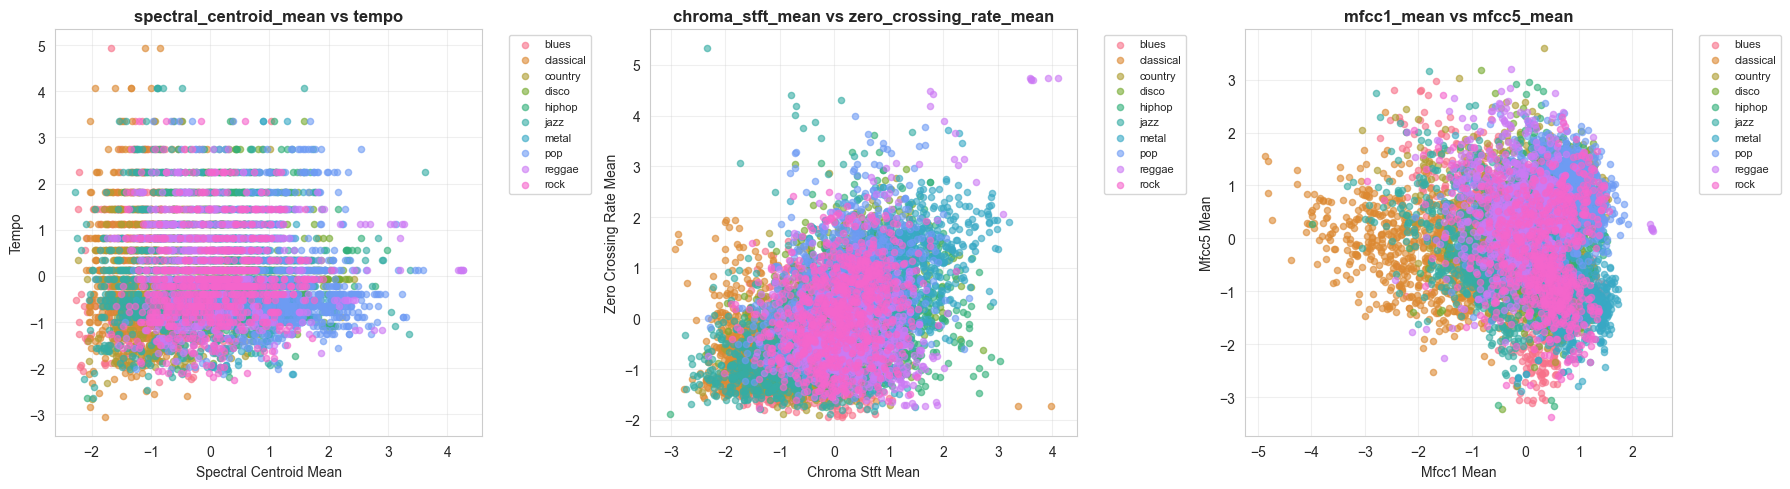


✓ Scatter plots reveal potential clustering of genres in feature space.


In [401]:
# Scatter plot of selected feature pairs colored by genre
print("="*80)
print("BIVARIATE ANALYSIS - FEATURE RELATIONSHIPS")
print("="*80)

# Select features for pairwise comparison
feature_pairs = [
    ('spectral_centroid_mean', 'tempo'),
    ('chroma_stft_mean', 'zero_crossing_rate_mean'),
    ('mfcc1_mean', 'mfcc5_mean')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (feat1, feat2) in enumerate(feature_pairs):
    ax = axes[idx]
    
    # Scatter plot colored by genre
    genres = sorted(X_analysis['genre'].unique())
    colors = sns.color_palette("husl", len(genres))
    
    for genre, color in zip(genres, colors):
        mask = X_analysis['genre'] == genre
        ax.scatter(X_analysis.loc[mask, feat1], X_analysis.loc[mask, feat2], 
                  c=[color], label=genre, alpha=0.6, s=20)
    
    ax.set_xlabel(feat1.replace('_', ' ').title(), fontsize=10)
    ax.set_ylabel(feat2.replace('_', ' ').title(), fontsize=10)
    ax.set_title(f'{feat1} vs {feat2}', fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Scatter plots reveal potential clustering of genres in feature space.")


### 4.3 Correlation Analysis

Understanding feature correlations helps identify redundant features and important relationships.


CORRELATION ANALYSIS


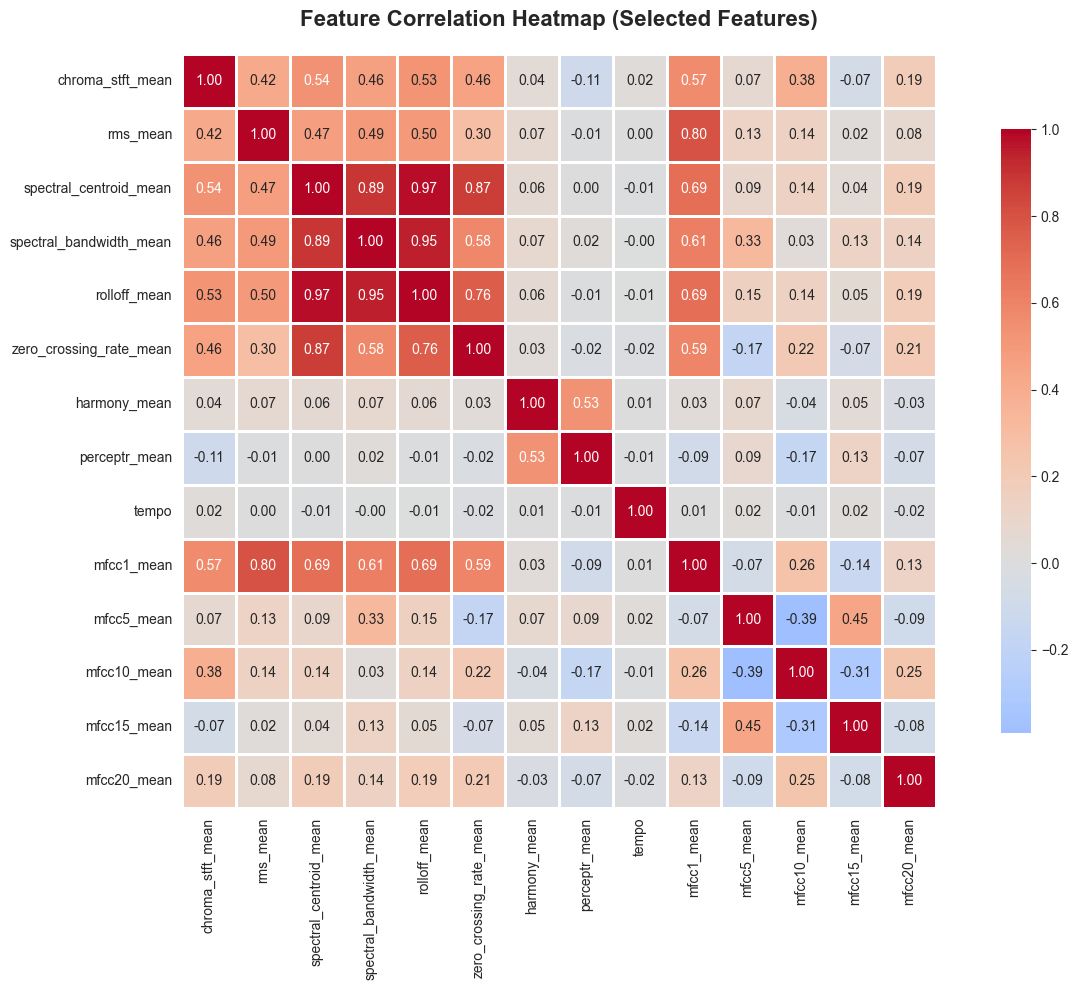


✓ Correlation heatmap shows relationships between features.
  - Strong positive correlation (red): Features move together
  - Strong negative correlation (blue): Features move oppositely
  - Weak correlation (white/gray): Features are independent


In [402]:
# Correlation heatmap for key features
print("="*80)
print("CORRELATION ANALYSIS")
print("="*80)

# Select a subset of features for correlation analysis (too many to show all)
feature_subset = [
    'chroma_stft_mean', 'rms_mean', 'spectral_centroid_mean', 
    'spectral_bandwidth_mean', 'rolloff_mean', 'zero_crossing_rate_mean',
    'harmony_mean', 'perceptr_mean', 'tempo',
    'mfcc1_mean', 'mfcc5_mean', 'mfcc10_mean', 'mfcc15_mean', 'mfcc20_mean'
]

correlation_matrix = X[feature_subset].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap (Selected Features)', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n✓ Correlation heatmap shows relationships between features.")
print("  - Strong positive correlation (red): Features move together")
print("  - Strong negative correlation (blue): Features move oppositely")
print("  - Weak correlation (white/gray): Features are independent")


In [403]:
# Identify highly correlated feature pairs
print("\nHighly Correlated Feature Pairs (|correlation| > 0.8):")
print("="*80)

# Get upper triangle of correlation matrix
upper_triangle = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)

# Find highly correlated pairs
high_corr_pairs = []
for i, feat1 in enumerate(correlation_matrix.columns):
    for j, feat2 in enumerate(correlation_matrix.columns):
        if upper_triangle[i, j]:
            corr_value = correlation_matrix.iloc[i, j]
            if abs(corr_value) > 0.8:
                high_corr_pairs.append((feat1, feat2, corr_value))

# Display them
if high_corr_pairs:
    for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"{feat1} <-> {feat2}: {corr:.3f}")
else:
    print("No highly correlated pairs found in selected features.")

print(f"\nNote: Feature engineering or dimensionality reduction could be considered")
print(f"if many features are highly correlated.")



Highly Correlated Feature Pairs (|correlation| > 0.8):
spectral_centroid_mean <-> rolloff_mean: 0.975
spectral_bandwidth_mean <-> rolloff_mean: 0.951
spectral_centroid_mean <-> spectral_bandwidth_mean: 0.891
spectral_centroid_mean <-> zero_crossing_rate_mean: 0.868

Note: Feature engineering or dimensionality reduction could be considered
if many features are highly correlated.


---
### Summary and Next Steps

The dataset has been successfully preprocessed and is ready for model training. Here's what we accomplished:

**✓ Completed Steps:**
1. ✓ Data Collection and Exploration
2. ✓ Missing Values Handling  
3. ✓ Duplicate Removal
4. ✓ Outlier Detection
5. ✓ Categorical Feature Encoding
6. ✓ Feature Scaling
7. ✓ Dimensionality Analysis (PCA and LDA)
8. ✓ Exploratory Data Analysis

**Data Ready for Training:**
- **df_preprocessed_pca**: Features after applying PCA
- **df_preprocessed_lda**: Features after applying LDA
- **y_genres**: Original genre names for reference

**Next Steps:**
- Train-test split
- Model selection and training
- Model evaluation
- Model Deployment

The cleaned dataset is now ready for building a music genre classification model!


In [404]:
from sklearn.pipeline import Pipeline

# Build pipeline1
pipeline_pca = Pipeline(steps=[
    ('scaler', scaler),          # Step 1: Feature scaling
    ('pca', pca),                # Step 2: PCA
])

# Build pipeline2
pipeline_lda = Pipeline(steps=[
    ('scaler', scaler),          # Step 1: Feature scaling
    ('lda', lda),                # Step 2: LDA
])


print("✓ Pipeline created successfully!")

✓ Pipeline created successfully!


In [405]:
import joblib

# Save the pipelines
joblib.dump(pipeline_pca, 'pipeline_pca.pkl')
joblib.dump(pipeline_lda, 'pipeline_lda.pkl')

print("Pipelines saved successfully!")

Pipelines saved successfully!
